Range resolution: 0.0488 m
Wavelength: 4.98 mm
Frames: 500
Locked onto Anchor Bin: 22 (1.073 m)

========= PHASE-TRACKED RESULTS =========
True distance: 1.04 m
Mean measured: 1.0735 m
Bias: 33.48 mm
Std dev (noise): 1.69 mm
RMSE: 33.52 mm


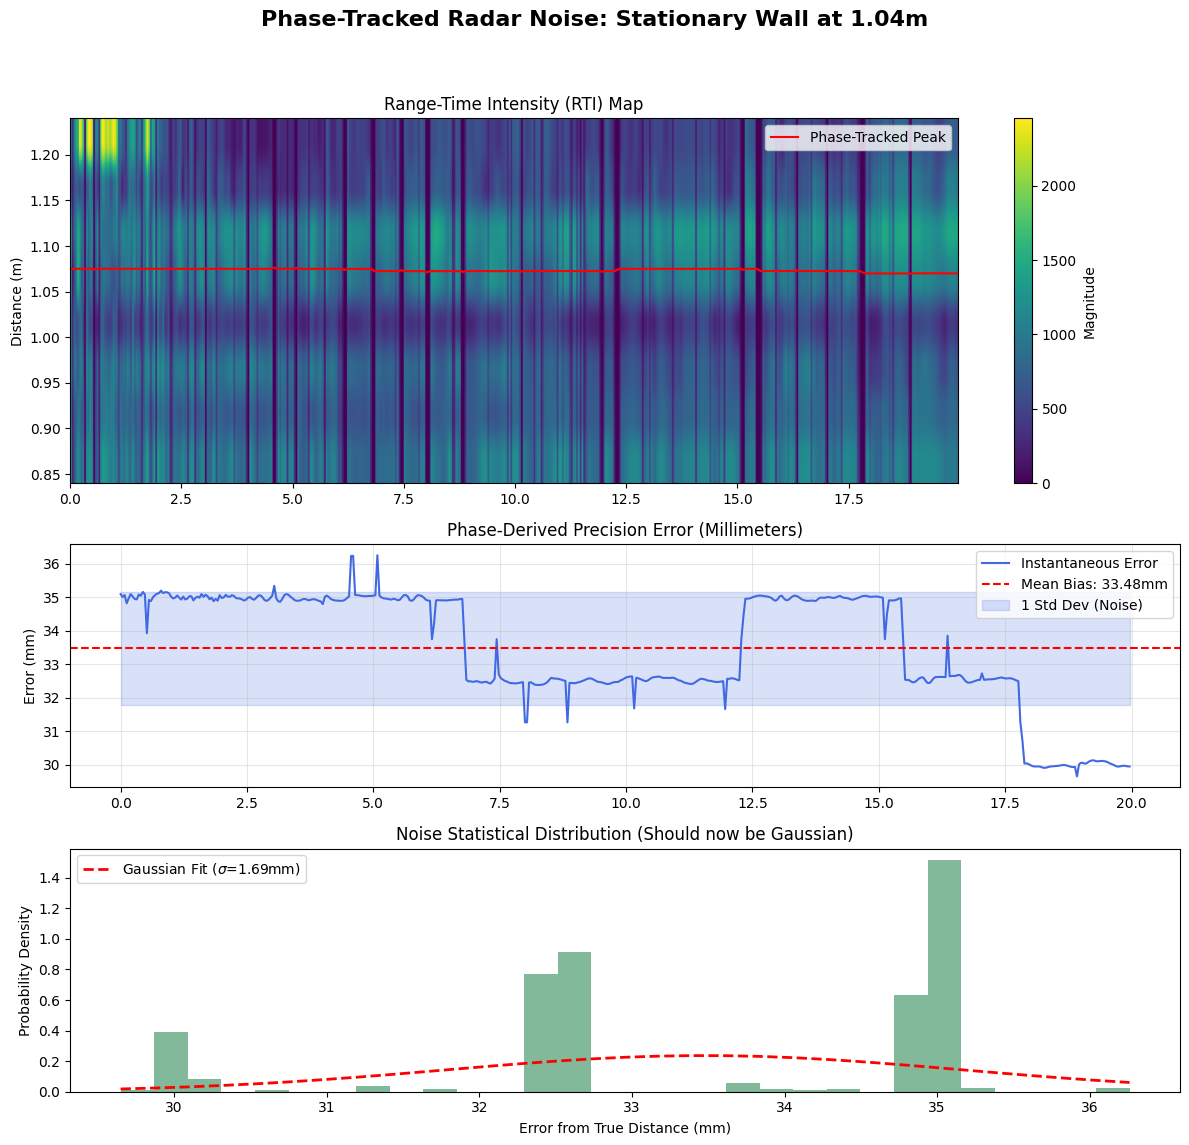

In [ ]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ---------------- USER INPUT ---------------- #
BIN_FILE = r"\\wsl.localhost\Ubuntu-24.04\home\sisig\Dissertation-RobotAutomation\ros_jazzy_ws\src\my_bot_controller\wall1.04.bin"
TRUE_DISTANCE_M = 1.04# <-- CHANGE for each experiment
NUM_CHIRPS = 128
NUM_SAMPLES = 256
NUM_RX = 4
FRAME_RATE = 25.0

# Radar config
START_FREQ_GHZ = 60.25 
FREQ_SLOPE_MHZ_US = 60.0
SAMPLE_RATE_KSPS = 5000.0

# Search window (meters)
SEARCH_START_M = TRUE_DISTANCE_M - 0.2
SEARCH_END_M   = TRUE_DISTANCE_M + 0.2
# ------------------------------------------- #

# Constants & Derived parameters
c = 299792458.0
sample_rate_hz = SAMPLE_RATE_KSPS * 1e3
freq_slope_hz_s = FREQ_SLOPE_MHZ_US * 1e12
adc_capture_time = NUM_SAMPLES / sample_rate_hz
bandwidth = freq_slope_hz_s * adc_capture_time
range_resolution = c / (2 * bandwidth)
wavelength = c / (START_FREQ_GHZ * 1e9)
num_range_bins = NUM_SAMPLES // 2

print(f"Range resolution: {range_resolution:.4f} m")
print(f"Wavelength: {wavelength*1000:.2f} mm")

# ---------------- LOAD DATA ---------------- #
raw = np.fromfile(BIN_FILE, dtype=np.int16)
vals_per_frame = NUM_CHIRPS * NUM_SAMPLES * NUM_RX * 2
NUM_FRAMES = len(raw) // vals_per_frame
print(f"Frames: {NUM_FRAMES}")

raw = raw.reshape(NUM_FRAMES, NUM_CHIRPS, NUM_SAMPLES, NUM_RX, 2)
data = raw[..., 0] + 1j * raw[..., 1]

# ---------------- RANGE FFT ---------------- #
window = np.hanning(NUM_SAMPLES).reshape(1,1,-1,1)
data_win = data * window
range_fft = np.fft.fft(data_win, axis=2)
range_fft = range_fft[:, :, :num_range_bins, :]

# ---------------- PHASE TRACKING ---------------- #
search_start_bin = max(1, int(SEARCH_START_M / range_resolution))
search_end_bin   = min(num_range_bins, int(SEARCH_END_M / range_resolution))

global_mag = np.mean(np.abs(range_fft), axis=(0, 1, 3)) # Average over frames, chirps, RX
anchor_bin = search_start_bin + np.argmax(global_mag[search_start_bin:search_end_bin])
base_distance = anchor_bin * range_resolution
print(f"Locked onto Anchor Bin: {anchor_bin} ({base_distance:.3f} m)")


complex_signal = np.mean(range_fft[:, :, anchor_bin, :], axis=(1, 2))
raw_phase = np.angle(complex_signal)
unwrapped_phase = np.unwrap(raw_phase)

displacement = -unwrapped_phase * (wavelength / (4 * np.pi))

displacement -= np.mean(displacement)
fine_distances = base_distance + displacement
errors = fine_distances - TRUE_DISTANCE_M

# ---------------- ERROR METRICS ---------------- #
bias = np.mean(errors)
std_dev = np.std(errors)
rmse = np.sqrt(np.mean(errors**2))

print("\n========= PHASE-TRACKED RESULTS =========")
print(f"True distance: {TRUE_DISTANCE_M:.2f} m")
print(f"Mean measured: {np.mean(fine_distances):.4f} m")
print(f"Bias: {bias*1000:.2f} mm")
print(f"Std dev (noise): {std_dev*1000:.2f} mm")
print(f"RMSE: {rmse*1000:.2f} mm")

# ---------------- PLOTS ---------------- #
time_axis = np.arange(NUM_FRAMES) / FRAME_RATE
rti_data = np.mean(np.abs(range_fft[:, :, search_start_bin:search_end_bin, :]), axis=(1, 3))

fig, axes = plt.subplots(3, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [1.5, 1, 1]})
fig.suptitle(f'Phase-Tracked Radar Noise: Stationary Wall at {TRUE_DISTANCE_M}m', fontsize=16, fontweight='bold')

# 1. Range-Time Intensity (Heatmap)
im = axes[0].imshow(rti_data.T, aspect='auto', origin='lower', 
                    extent=[0, time_axis[-1], SEARCH_START_M, SEARCH_END_M], cmap='viridis')
axes[0].plot(time_axis, fine_distances, color='red', linewidth=1.5, label='Phase-Tracked Peak')
axes[0].set_title("Range-Time Intensity (RTI) Map")
axes[0].set_ylabel("Distance (m)")
axes[0].legend(loc='upper right')
fig.colorbar(im, ax=axes[0], label="Magnitude")

# 2. Precision Error (Millimeters)
axes[1].plot(time_axis, errors * 1000, color='royalblue', label='Instantaneous Error')
axes[1].axhline(bias * 1000, color='red', linestyle='--', label=f'Mean Bias: {bias*1000:.2f}mm')
axes[1].fill_between(time_axis, (bias-std_dev)*1000, (bias+std_dev)*1000, color='royalblue', alpha=0.2, label='1 Std Dev (Noise)')
axes[1].set_title("Phase-Derived Precision Error (Millimeters)")
axes[1].set_ylabel("Error (mm)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# 3. Probability Density of Noise
mu, sigma = np.mean(errors*1000), np.std(errors*1000)
n, bins, patches = axes[2].hist(errors*1000, bins=30, density=True, alpha=0.6, color='seagreen')
y = stats.norm.pdf(bins, mu, sigma)
axes[2].plot(bins, y, 'r--', linewidth=2, label=f'Gaussian Fit ($\sigma$={sigma:.2f}mm)')
axes[2].set_title("Noise Statistical Distribution (Should now be Gaussian)")
axes[2].set_xlabel("Error from True Distance (mm)")
axes[2].set_ylabel("Probability Density")
axes[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()